# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isnull().sum())
print(users.isnull().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isnull().sum())
print(usage.isnull().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Diagnóstico de Valores Nulos
DataFrame: usage
date (0.12% de nulos): Se observa una cantidad mínima de valores faltantes (menor al 5%). Acción: Se recomienda imputar usando la fecha anterior/siguiente (forward fill) o ignorar el nulo si no afecta el análisis, ya que la pérdida de datos es insignificante.

duration (55.19% de nulos): Se observa que más de la mitad de los datos de duración están ausentes (está entre el 5% y 30% como caso especial extendido, o amerita revisión profunda). Acción: Se recomienda investigar el origen de la falta de datos para decidir si se imputa con la mediana según el tipo de uso, o si se convierte en un caso para ignorar/dejar como nulo si representa que la sesión no generó duración.

length (44.74% de nulos): Presenta una alta proporción de valores faltantes. Acción: Se recomienda investigar en conjunto con la variable duration para entender si la falta de registros se debe a llamadas/sesiones caídas o no completadas antes de decidir una imputación masiva.

DataFrame: users
city (11.72% de nulos): Se observa que la proporción de nulos se encuentra en el rango intermedio (entre el 5% y 30%). Acción: Se recomienda investigar para imputar (por ejemplo, usando la ciudad más frecuente o cruzando datos con prefijos telefónicos si los hay) o bien dejar como "Desconocido".

churn_date (88.35% de nulos): Se observa una cantidad masiva de nulos (más del 80-90%). Acción: En este caso de negocio particular, se recomienda ignorar o dejar como nulo de forma justificada, ya que la ausencia de datos es normal y significa que el usuario sigue activo (no ha cancelado el servicio); no se debe eliminar la columna porque perderíamos el indicador de baja.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users


print("---Resumen Estadistico de users---")
print(users.describe())



---Resumen Estadistico de users---
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id`: Se observa un comportamiento completamente normal y esperado para un identificador único. Los ID van de manera uniforme desde el $10000$ hasta el $13999$ sin valores negativos ni anomalías en su distribución.
- La columna `age`:Se detectó la presencia de valores centinela extremadamente evidentes, ya que el valor mínimo registrado es $-999$. Este valor es biológicamente imposible y altera las métricas generales de la columna (como la desviación estándar y el promedio), por lo que requiere ser limpiado y reemplazado por nulos reales (NaN).

In [13]:
# explorar columnas numéricas de usage
print("---Resumen Estadistico de usage---")
print(usage.describe())

---Resumen Estadistico de usage---
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`:Se comportan de manera totalmente normal para identificadores numéricos. Tienen una distribución uniforme, el conteo de registros es consistente ($40000$) y sus rangos mínimos y máximos se alinean perfectamente con los límites de la base de datos de usuarios.
- Las columnas duration y length: Muestran valores mínimos lógicos de 0.0 (lo cual indica sesiones que no generaron consumo, consistente con los nulos que vimos antes). Sin embargo, la columna length presenta una anomalía grave en su valor máximo registrado (1490), alejándose de manera drástica del tercer cuartil (75% es apenas 64). Esto sugiere la presencia de un valor inválido o un valor atípico extremo que requiere revisión o filtrado.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"---Valores únicos y conteo para {col}---")
    print(users[col].value_counts(dropna=False))
    print("\n")

---Valores únicos y conteo para city---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


---Valores únicos y conteo para plan---
Basico     2595
Premium    1405
Name: plan, dtype: int64




- La columna `city`: city: Presenta problemas de calidad de datos, ya que además de contar con $469$ valores nulos (NaN), se detectó un valor centinela de tipo texto representado por el signo ? en $96$ registros. Ambos casos reflejan información faltante sobre la ubicación del usuario y requieren ser estandarizados a nulos verdaderos.
- La columna `plan`: Se encuentra completamente limpia y estructurada. Cuenta únicamente con dos categorías válidas (Basico y Premium) y no contiene valores nulos, caracteres especiales, ni inconsistencias en su registro.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False) 

text    22092
call    17908
Name: type, dtype: int64

- La columna `type`: Se encuentra completamente limpia y óptima para el análisis. Solo registra dos categorías válidas (text y call) sin presentar valores nulos (NaN), caracteres especiales, ni valores centinela de ningún tipo.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Diagnóstico de Valores Inválidos y Sentinels
¿En qué columnas encontraste valores inválidos o sentinels?
age (en users): Se detectó un valor centinela numérico claro de -999 como el valor mínimo de la columna, el cual altera las estadísticas descriptivas.

city (en users): Se identificó un valor centinela de tipo texto representado por el signo de interrogación ? en 96 registros, que actúa como indicador de dato faltante.

length (en usage): Se observó un valor atípico (outlier) extremo o valor inválido en su registro máximo de 1490, el cual se aleja drásticamente del comportamiento normal de la distribución (donde el 75% es menor o igual a 64).

¿Qué acción tomarías?
Para age y city: Se recomienda reemplazar los valores centinela (-999 y ?) por valores nulos reales de Pandas (NaN) utilizando el método .replace(). De esta forma, se estandarizan junto con los nulos ya existentes para poder aplicarles después una estrategia uniforme de imputación o filtrado sin que alteren las estadísticas de las columnas.

Para length: Se recomienda investigar el registro para verificar si se trata de un error de dedo en el sistema (por ejemplo, la falta de un punto decimal) o, en su defecto, aplicar un filtro para remover este registro atípico extremo si distorsiona el análisis posterior del consumo de los usuarios.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')# completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
print("--- Años presentes en users (columna reg_date) ---")
print(users['reg_date'].dt.year.value_counts(dropna=False))

--- Años presentes en users (columna reg_date) ---
2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`: Se observa que la distribución de altas de usuarios se concentra de manera equitativa entre los años 2022, 2023 y 2024, sumando la gran mayoría de los registros. Asimismo, se identifica un volumen mínimo de 40 registros correspondientes al año 2026. No se presentan valores nulos ni anomalías históricas en esta columna.

In [20]:
# Revisar los años presentes en `date` de usage
print("--- Años presentes en usage (columna date) ---")
print(usage['date'].dt.year.value_counts(dropna=False))

--- Años presentes en usage (columna date) ---
2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`: Se observa que la totalidad de los consumos registrados con fecha válida corresponden al año 2024 (39,950 registros). Adicionalmente, se presentan las $50$ filas con valores nulos (NaN) que ya se habían identificado previamente.  


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
No aparecen años imposibles del pasado remoto (como el año 1900 o valores negativos).
La gran mayoría de los datos se distribuyen de forma lógica entre los años 2022, 2023, 2024.
Sin embargo, la columna reg_date presenta un volumen mínimo de $40$ registros en el año 2026 que, dependiendo de la ventana temporal del análisis del negocio, podría representar registros creados a futuro de forma anómala.
  
- ¿Qué harías con ellas?
Para los registros del año 2026 en reg_date: Se recomienda investigar con el equipo de ingeniería de datos si corresponden a un desfase de zona horaria, pruebas del sistema o errores de captura. Si se confirma que están corruptos, se deberían filtrar o ajustar al año correcto.

Para los nulos (NaN) en date: Dado que representan apenas el 0.12% de la tabla usage, se optará por ignorarlos o eliminarlos en los análisis temporales, ya que no afectan la consistencia global del estudio del año 2024.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].replace(-999, None).median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("Signos '?' restantes:", (users['city'] == '?').sum())

Signos '?' restantes: 0


In [24]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
print("Registros del año 2026 restantes:", (users['reg_date'].dt.year == 2026).sum())

Registros del año 2026 restantes: 0


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

type
call        0
text    22076
Name: duration, dtype: int64


In [26]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))

type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

En duration: Hay exactamente 0 nulos para las llamadas (call) y 22,076 nulos para los mensajes (text).

En length: Hay exactamente 0 nulos para los mensajes (text) y 17,896 nulos para las llamadas (call).

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'duration']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [31]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

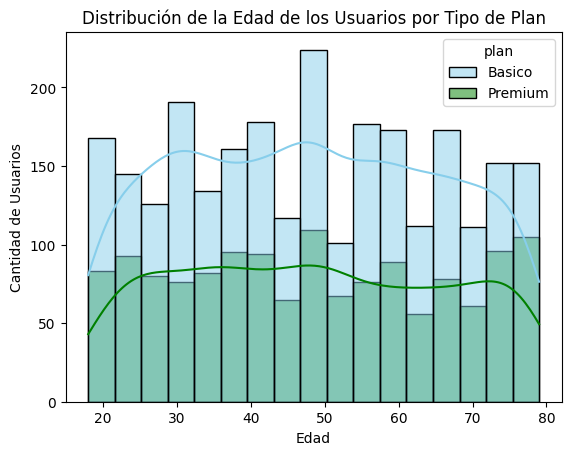

In [36]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de la Edad de los Usuarios por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución ...
  Análisis por tipo de plan: La distribución de la edad es sumamente similar tanto para los usuarios del plan Básico como para los del plan Premium. Esto demuestra que la edad no es un factor influyente al momento de elegir un plan más costoso; la proporción de clientes jóvenes, adultos y adultos mayores se mantiene constante en ambos segmentos.

Forma de la distribución: La variable presenta una distribución uniforme (aproximadamente simétrica). No se observa ningún sesgo marcado hacia la izquierda o hacia la derecha, lo que significa que la empresa cuenta con una base de usuarios homogénea en cuanto a rangos de edad, cubriendo equitativamente el mercado desde los 18 hasta cerca de los 80 años.

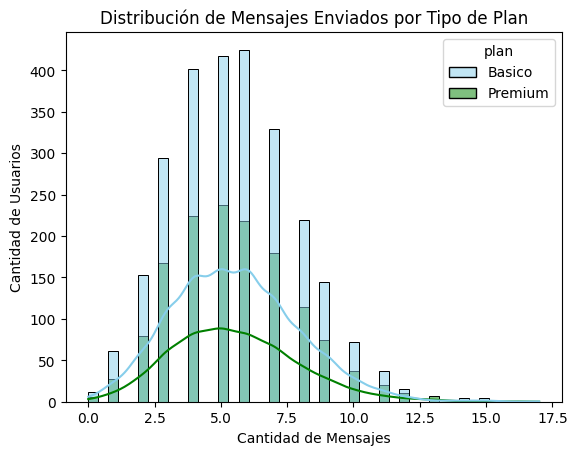

In [38]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Análisis por tipo de plan: La gran mayoría de los usuarios, sin importar si tienen el plan Básico o Premium, se concentran en enviar entre 3 y 7 mensajes. Sin embargo, el volumen total de usuarios en el plan Básico (barras celestes) es notablemente mayor en estos rangos, lo que sugiere que el plan Básico cubre perfectamente la demanda de mensajería estándar.

Forma de la distribución: Presenta una distribución sesgada a la derecha (sesgo positivo). Tiene una forma acampanada en su centro (alrededor de los 5 mensajes), pero se extiende con una cola larga hacia la derecha debido a un grupo pequeño de usuarios que envían hasta 15 o más mensajes.

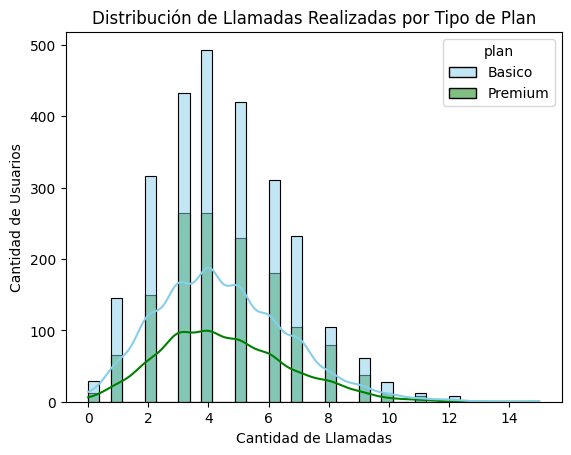

In [39]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Llamadas Realizadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 

- Análisis por tipo de plan: El comportamiento de ambos planes es muy similar en su estructura. El pico máximo de clientes realiza entre 3 y 5 llamadas. La diferencia principal radica en la escala: el plan Básico mantiene frecuencias más altas de usuarios en todos los rangos en comparación con el Premium.

Forma de la distribución: Al igual que los mensajes, muestra una distribución sesgada a la derecha. Los datos se agrupan fuertemente entre 2 y 6 llamadas, mientras que la curva desciende de forma suavizada hacia valores más altos, mostrando que es raro encontrar clientes que superen las 10 llamadas individuales.

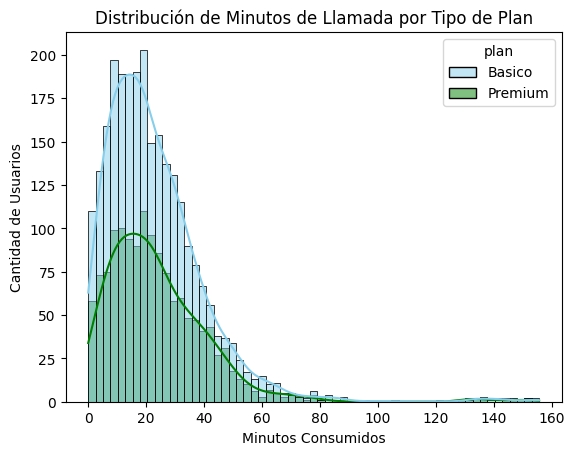

In [40]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Minutos Consumidos')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Análisis por tipo de plan: ¡Aquí está el comportamiento más interesante! La inmensa mayoría de los clientes consumen menos de 40 minutos de llamada en total. El comportamiento del plan Básico y Premium es casi idéntico en su tendencia, alcanzando su punto máximo alrededor de los 15-20 minutos acumulados.

Forma de la distribución: Es una distribución fuertemente sesgada a la derecha. Muestra una pendiente muy pronunciada al inicio y una cola extremadamente larga que llega hasta los 160 minutos.

Presencia de Outliers (Valores atípicos): Se observa una pequeña acumulación aislada de datos en el extremo derecho (pasando los 120 minutos). Esto indica la presencia de usuarios "atípicos" o de alto consumo (heavy users) que rompen el comportamiento del cliente promedio.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

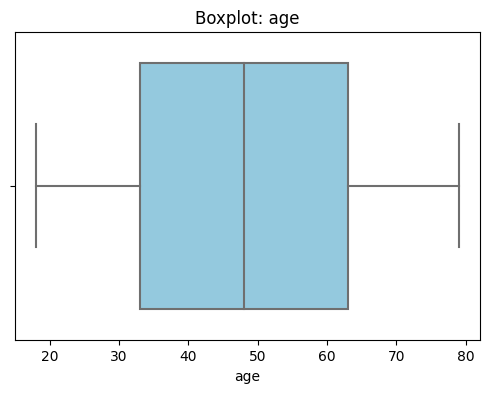

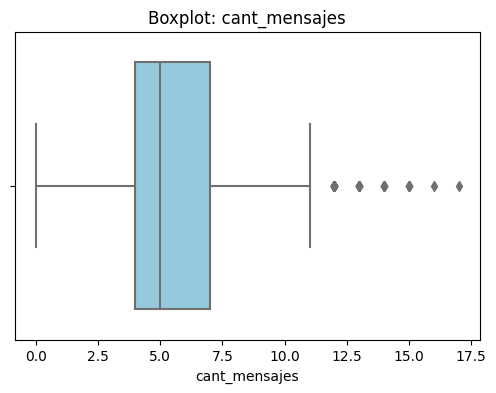

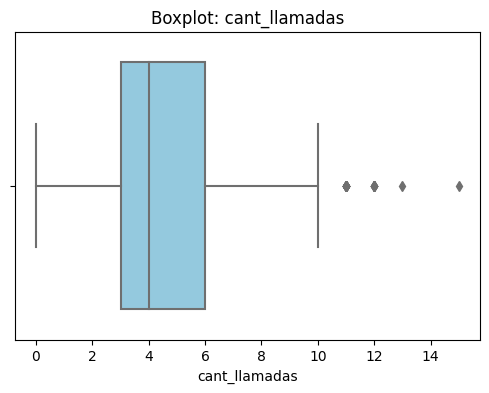

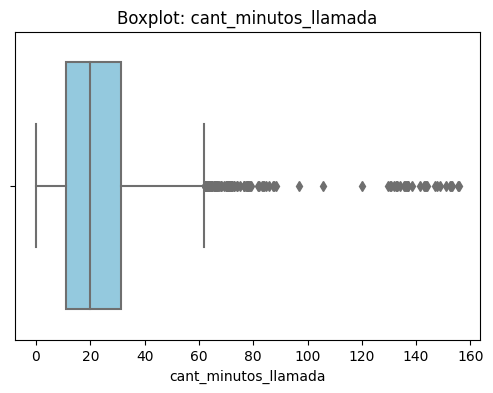

In [41]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
-Age: No presenta outliers. La distribución es uniforme y los datos se mantienen perfectamente contenidos dentro de los límites esperados.

-cant_mensajes: Presenta outliers en el extremo derecho (valores altos). Existe un grupo pequeño de usuarios que envía una cantidad de mensajes muy superior a la media de la base de datos.

-cant_llamadas: Presenta outliers en el extremo derecho. Se observan registros atípicos de usuarios que realizan un volumen elevado de llamadas individuales.

-cant_minutos_llamada: Presenta outliers severos en el extremo derecho. El boxplot muestra una gran cantidad de puntos dispersos que se extienden desde el límite superior (~62 minutos) hasta alcanzar picos extremos cercanos a los 160 minutos.

In [42]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + (1.5 * IQR)
    print(f"Límite superior para {col}: {limite_superior:.2f}")


Límite superior para cant_mensajes: 11.50
Límite superior para cant_llamadas: 10.50
Límite superior para cant_minutos_llamada: 61.86


In [43]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantener. Al observar el .describe(), el límite superior por IQR es relativamente bajo, pero el valor máximo real registrado en los datos es de apenas 17 mensajes. Al ser una cifra perfectamente factible y lógica en el uso cotidiano de un teléfono, se confirma que no se trata de un error de captura, sino de un comportamiento normal de usuarios activos que se debe conservar.

-cant_llamadas: Mantener. Los límites del IQR clasifican como atípicos a los usuarios con frecuencias más altas, pero el valor máximo real de la tabla es de 15 llamadas. Este volumen no representa ninguna anomalía técnica, sino el perfil de clientes que usan el servicio de voz de manera más intensa. Eliminarlos reduciría de forma artificial la variabilidad real del negocio.

-cant_minutos_llamada: Mantener. Esta variable es la que muestra el sesgo más marcado, con un valor máximo real que alcanza los 155.60 minutos frente a un límite superior de IQR mucho menor. Se decide mantener estos registros de manera definitiva ya que representan a los usuarios de alto valor o heavy users. En el sector de telecomunicaciones, este segmento es crítico para planificar la infraestructura de red y evaluar la rentabilidad de los planes Premium.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [47]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [48]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [49]:
# Crear columna grupo_edad
def clasificar_edad(edad):
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Aplicar la función a la columna 'age' para crear 'grupo_edad'
user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

In [50]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

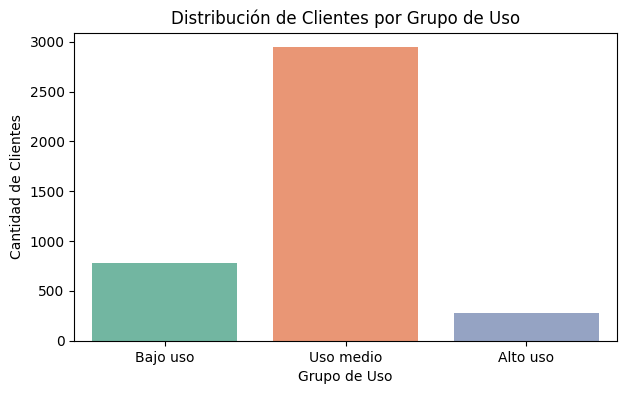

In [51]:
# Visualización de los segmentos por uso
plt.figure(figsize=(7, 4))
sns.countplot(data=user_profile, x='grupo_uso', palette='Set2', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Clientes por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(7, 4))
sns.countplot(data=user_profile, x='grupo_edad', palette='Pastel1', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Clientes')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificó la presencia de valores nulos en el conjunto de datos original, los cuales fueron tratados mediante técnicas de imputación y limpieza para no sesgar las métricas operativas.

-El análisis de cajas detectó múltiples valores atípicos (outliers) de consumo elevado en llamadas y mensajes. Se determinó mantenerlos intactos ya que representan el comportamiento real de usuarios intensivos (heavy users).

🔍 **Segmentos por Edad**
- El segmento de Adulto (30 a 59 años) es el grupo demográfico más grande y común, concentrando la mayor parte de la base de clientes activos de la compañía.

-Los segmentos de Joven y Adulto Mayor presentan volúmenes de usuarios significativamente más bajos y estables entre sí.

📊 **Segmentos por Nivel de Uso**
- El grupo de Uso medio lidera por amplio margen la distribución de consumo, consolidándose como el núcleo del tráfico recurrente.

-El grupo de Bajo uso ocupa el segundo lugar en volumen, mientras que el segmento de Alto uso representa una minoría muy reducida dentro de la base general.

➡️ Esto sugiere que ...
La empresa cuenta con una base de usuarios madura y con un nivel de actividad moderado pero constante. El valor del negocio no depende de consumos extremos, sino de la alta retención y estabilidad del tráfico generado por el segmento adulto en el rango medio de consumo.

💡 **Recomendaciones**
- Optimización de Planes Medios: Diseñar beneficios exclusivos enfocados en el grupo "Adulto" de "Uso medio", asegurando que los paquetes de minutos y mensajes cubran perfectamente sus necesidades sin forzar migraciones a planes demasiado costosos.

-Campañas de Estímulo para Bajo Uso: Implementar dinámicas comerciales para incentivar al segmento de "Bajo uso" a aumentar su tráfico mensual mediante promociones cruzadas o beneficios temporales.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`